# Tugas 7 | Analisis PageRank Dataset uts_email

1. Graph hubungan antar email
2. Visualisasi graf
3. 5 email dengan PageRank tertinggi

### import library

In [1]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [2]:
# Baca dataset email
df_email = pd.read_csv("uts_email.csv", encoding='ISO-8859-1')
df_email

,id,Text,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,1,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,2,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,3,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,4,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,5,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN
...,...,...,...,...,...
5567,5568,This is the 2nd time we have tried 2 contact u...,NaN,NaN,NaN
5568,5569,Will Ì_ b going to esplanade fr home?,NaN,NaN,NaN
5569,5570,"Pity, * was in mood for that. So...any other s...",NaN,NaN,NaN
5570,5571,The guy did some bitching but I acted like i'd...,NaN,NaN,NaN


In [3]:
# Pastikan kolom teks ada
if 'clean_text' not in df_email.columns:
    if 'Text' in df_email.columns:
        df_email['clean_text'] = df_email['Text']
    else:
        raise ValueError("Kolom 'Text' atau 'clean_text' tidak ditemukan di dataset email.")

In [4]:
# Ubah teks ke representasi TF-IDF
vectorizer_email = TfidfVectorizer(max_df=0.9, min_df=2, stop_words='english')
X_email = vectorizer_email.fit_transform(df_email['clean_text'])

In [5]:
# Hitung kemiripan antar email
sim_email = cosine_similarity(X_email)

In [6]:
# Bangun graph (threshold 0.3)
G_email = nx.Graph()
for i in range(len(sim_email)):
    for j in range(i + 1, len(sim_email)):
        if sim_email[i, j] > 0.3:
            G_email.add_edge(i, j, weight=sim_email[i, j])

print(f"Jumlah Node (email): {G_email.number_of_nodes()}")
print(f"Jumlah Edge (email): {G_email.number_of_edges()}")

Jumlah Node (email): 5252
Jumlah Edge (email): 37209


In [7]:
# Hitung PageRank
pagerank_email = nx.pagerank(G_email)
sorted_pr_email = sorted(pagerank_email.items(), key=lambda x: x[1], reverse=True)

print("\n5 Email dengan PageRank tertinggi:")
for idx, score in sorted_pr_email[:5]:
    text = df_email.iloc[idx]['clean_text'][:60].replace('\n', ' ')  # tampilkan potongan awal teks
    print(f"Email #{idx}: {text}... | PageRank: {score}")


5 Email dengan PageRank tertinggi:
Email #199: Found it, ENC  &lt;#&gt; , where you at?... | PageRank: 0.001552808878439422
Email #1578: How to Make a girl Happy? It's not at all difficult to make ... | PageRank: 0.001455912709568876
Email #286: Ok..... | PageRank: 0.0011683921235485606
Email #1272: Ok...... | PageRank: 0.0011683921235485606
Email #1318: Ok...... | PageRank: 0.0011683921235485606


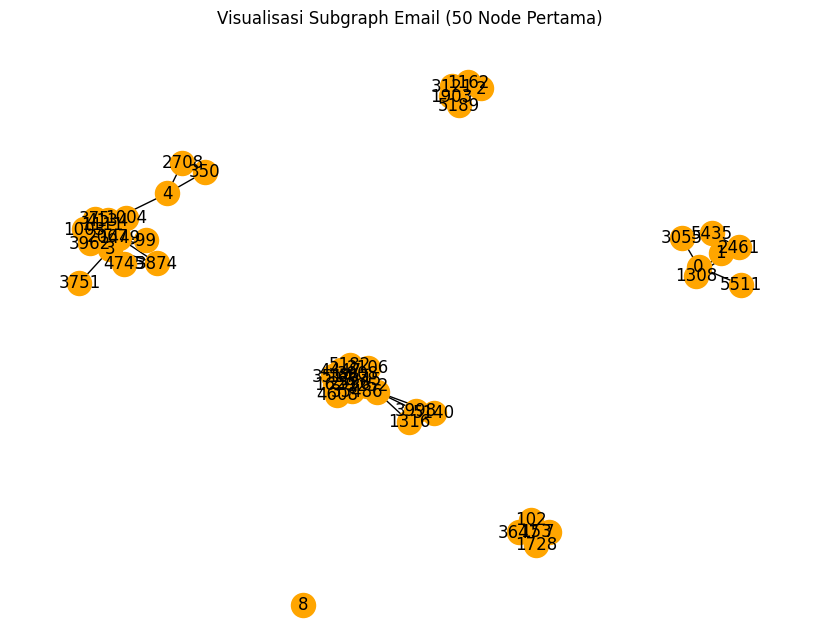

In [8]:
# Visualisasi graph email (subset kecil)
plt.figure(figsize=(8,6))
sub_email = list(G_email.nodes)[:50]
nx.draw(G_email.subgraph(sub_email), node_color='orange', with_labels=True)
plt.title("Visualisasi Subgraph Email (50 Node Pertama)")
plt.show()
